# Make Figure_S_pct_forest_burned.jpg
Reads pre-exported data from `../figure_data/figure_S_pct_forest_burned/` and produces the figure.

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from conus_biomass import dir_info
from conus_biomass.make_figures import figure_settings

DATA_DIR = "../figure_data/figure_S_pct_forest_burned/"

In [8]:
figure_settings.apply_style()

## Load data

In [9]:
tmean_forest = xr.open_dataset(DATA_DIR + "tmean_forest.nc")["tmean_forest"]
ppt_forest = xr.open_dataset(DATA_DIR + "ppt_forest.nc")["ppt_forest"] * 12
recent_burn = xr.open_dataset(DATA_DIR + "recent_burn.nc")["recent_burn"]

CA_boundary = gpd.read_file(DATA_DIR + "CA_boundary.gpkg")
PNW_boundary = gpd.read_file(DATA_DIR + "PNW_boundary.gpkg")

## Prepare westwide flat arrays and plot extent

In [10]:
x_all = tmean_forest.values.flatten()
y_all = ppt_forest.values.flatten()
extent = [np.nanmin(x_all), np.nanmax(x_all), np.nanmin(y_all), np.nanmax(y_all)]

## Make figure

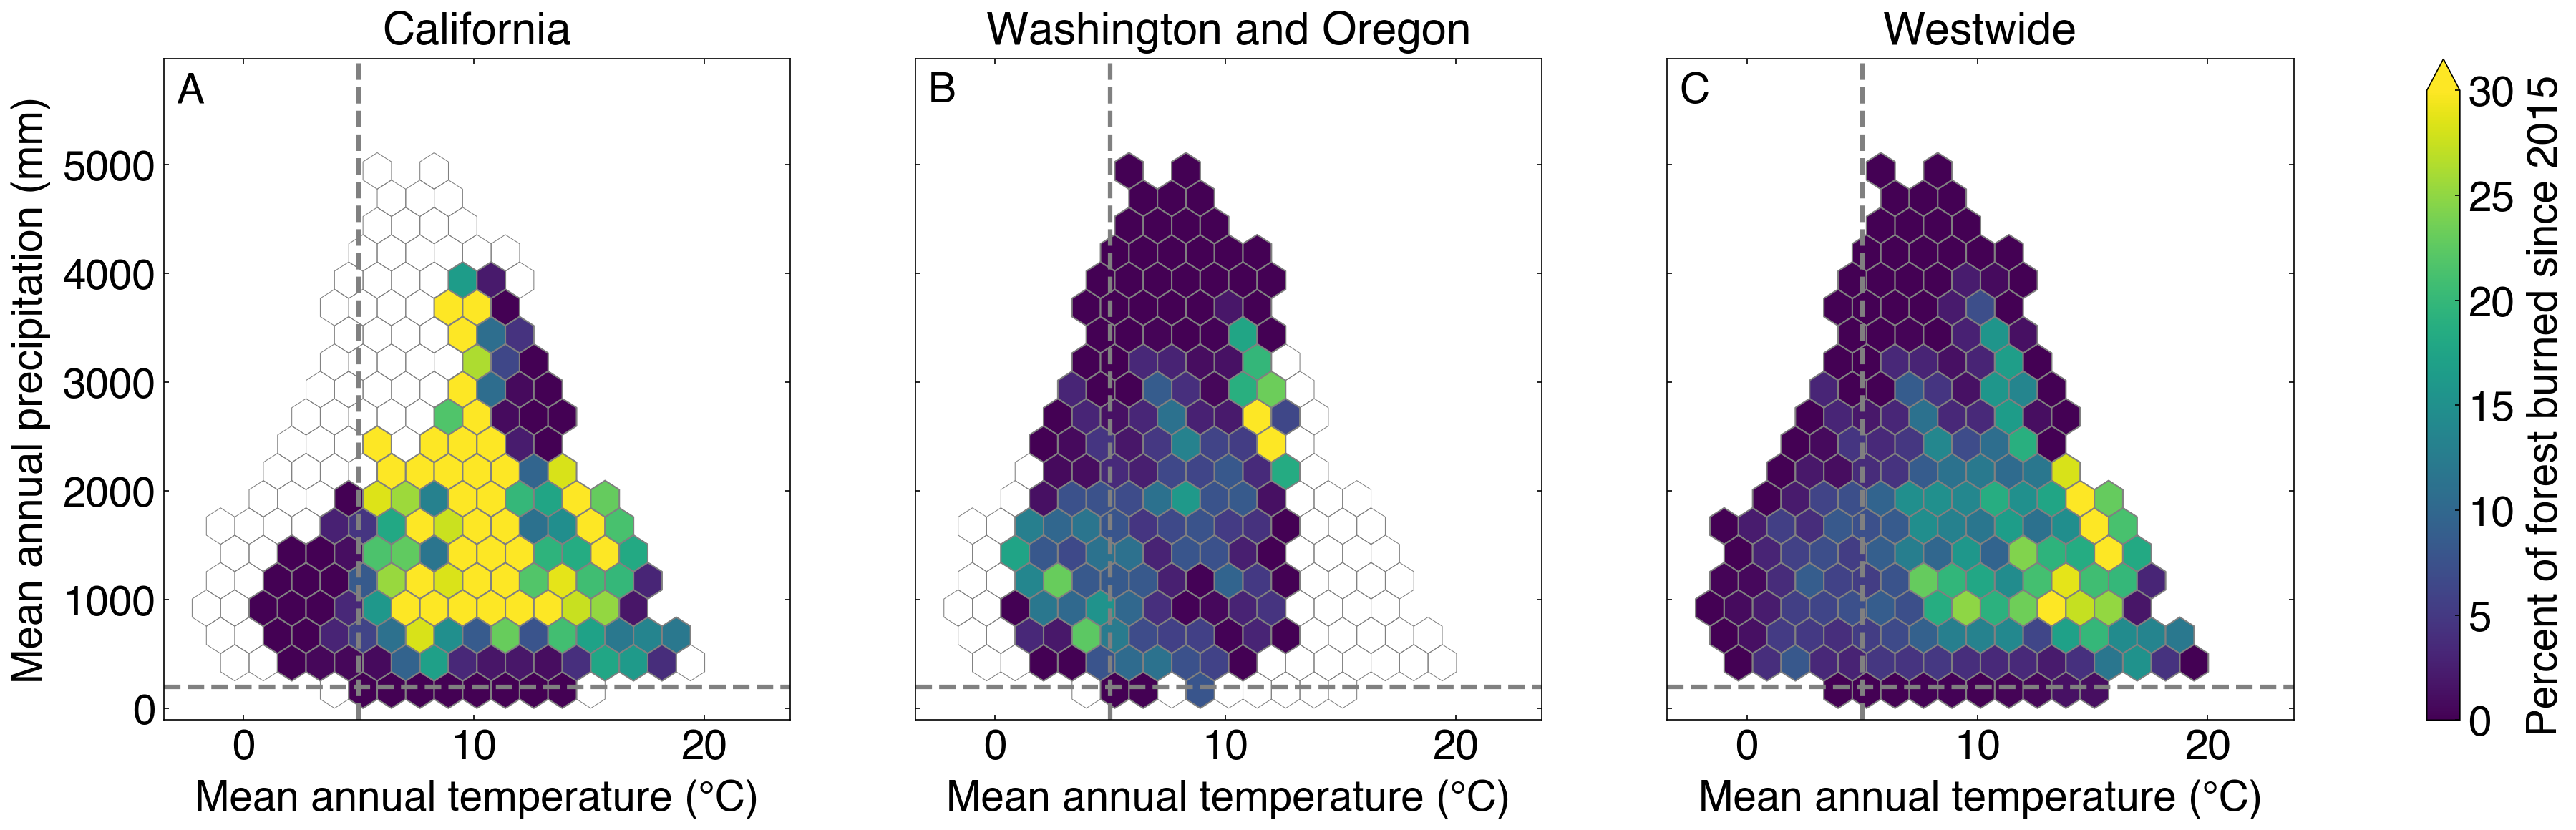

In [12]:
fig, axes = plt.subplots(figsize=(32, 8), nrows=1, ncols=3, sharey=True, sharex=True)

# Background hexbin outline on all panels
for ax in axes:
    ax.hexbin(
        x=x_all,
        y=y_all,
        C=recent_burn.values.flatten() * 100,
        gridsize=20,
        mincnt=25,
        extent=extent,
        facecolors="none",
        edgecolors="gray",
        linewidths=0.5,
    )
    ax.axhline(y=200, linewidth=3, linestyle="--", color="gray")
    ax.axvline(x=5, linewidth=3, linestyle="--", color="gray")

# California
axes[0].hexbin(
    x=tmean_forest.rio.clip(CA_boundary.geometry).values.flatten(),
    y=ppt_forest.rio.clip(CA_boundary.geometry).values.flatten(),
    C=recent_burn.rio.clip(CA_boundary.geometry).values.flatten() * 100,
    gridsize=20,
    mincnt=25,
    vmax=30,
    edgecolors="gray",
    extent=extent,
)
axes[0].set_title("California")

# Washington and Oregon
axes[1].hexbin(
    x=tmean_forest.rio.clip(PNW_boundary.geometry).values.flatten(),
    y=ppt_forest.rio.clip(PNW_boundary.geometry).values.flatten(),
    C=recent_burn.rio.clip(PNW_boundary.geometry).values.flatten() * 100,
    gridsize=20,
    mincnt=25,
    vmax=30,
    edgecolors="gray",
    extent=extent,
)
axes[1].set_title("Washington and Oregon")

# Westwide
im = axes[2].hexbin(
    x=x_all,
    y=y_all,
    C=recent_burn.values.flatten() * 100,
    gridsize=20,
    mincnt=25,
    vmax=30,
    edgecolors="gray",
    extent=extent,
)
axes[2].set_title("Westwide")

# Axis labels
for ax in axes:
    ax.set_xlabel("Mean annual temperature (°C)")
axes[0].set_ylabel("Mean annual precipitation (mm)")

# Panel labels
for ax, label in zip(axes, ["A", "B", "C"]):
    ax.text(0.02, 0.98, label, transform=ax.transAxes, fontweight="bold", va="top")

fig.colorbar(im, ax=axes, extend="max", label="Percent of forest burned since 2015")
plt.savefig(dir_info.dir_figures + "supp/Figure_S_pct_forest_burned.jpg", dpi=300)
plt.savefig(dir_info.dir_figures + "supp/Figure_S_pct_forest_burned.pdf")
plt.show()